In [46]:
import numpy as np
import pandas as pd
import sklearn
from matplotlib import pyplot as plt
import math
import os
import difflib

import scipy.sparse as sp

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [55]:
df = pd.read_csv("SpotifyFeatures.csv")
# numerical features
NUM_FEATURES = [
    "acousticness","danceability","duration_ms","energy","instrumentalness",
    "liveness","loudness","speechiness","tempo","valence"
]
#categorical features
CAT_FEATURES = ["genre", "key", "mode", "time_signature"]  # these are categorical in your file

for c in NUM_FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "popularity" in df.columns:
    df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")
else:
    df["popularity"] = np.nan

df = df.dropna(subset=["artist_name","track_name"] + NUM_FEATURES + CAT_FEATURES).copy()

df = df.drop_duplicates().copy()

# Deduplicate tracks (one row per track_id)
if "track_id" in df.columns:
    df["non_nulls"] = df.notna().sum(axis=1)

    df = (df.sort_values(["track_id","popularity","non_nulls"], ascending=[True, False, False])
            .drop_duplicates(subset=["track_id"], keep="first")
            .drop(columns=["non_nulls"])
            .copy())
else: #if track id doesnt exist
    df["non_nulls"] = df.notna().sum(axis=1)
    df = (df.sort_values(["artist_name","track_name","popularity","non_nulls"], ascending=[True, True, False, False])
            .drop_duplicates(subset=["artist_name","track_name"], keep="first")
            .drop(columns=["non_nulls"])
            .copy())

MIN_TRACKS_PER_ARTIST = 20
counts = df["artist_name"].value_counts()
df = df[df["artist_name"].isin(counts[counts >= MIN_TRACKS_PER_ARTIST].index)].copy()

print("Rows:", len(df))
print("Unique track_id:", df["track_id"].nunique() if "track_id" in df.columns else "N/A")
print("Duplicate track_id rows:", df.duplicated(subset=["track_id"]).sum() if "track_id" in df.columns else "N/A")
print("Duplicate (artist, track) rows:", df.duplicated(subset=["artist_name","track_name"]).sum())
df.head()
df

Rows: 122589
Unique track_id: 122589
Duplicate track_id rows: 0
Duplicate (artist, track) rows: 341


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
34788,Anime,Capcom Sound Team,Zangief's Theme,00021Wy6AyMbLP2tqij86e,13,0.2340,0.617,169173,0.862,0.976000,G,0.1410,-12.855,Major,0.0514,129.578,4/4,0.886
546,Movie,Henri Salvador,Coeur Brisé à Prendre - Remastered,000CzNKC8PEt1yC3L8dqwV,5,0.2490,0.518,130653,0.805,0.000000,F,0.3330,-6.248,Major,0.0407,79.124,4/4,0.841
136665,Reggae,Mike Love,Earthlings,000DfZJww8KiixTKuk9usJ,30,0.3660,0.631,357573,0.513,0.000004,D,0.1090,-6.376,Major,0.0293,120.365,4/4,0.307
14492,Dance,ZAYN,Still Got Time,000xQL6tZNLJzIrtIgxqSl,70,0.1310,0.748,188491,0.627,0.000000,G,0.0852,-6.029,Major,0.0644,120.963,4/4,0.524
169216,Comedy,Chad Daniels,Thanksgiving Chicken,0017XiMkqbTfF2AUOzlhj6,27,0.7920,0.536,127040,0.780,0.000000,F,0.7350,-9.449,Minor,0.9450,173.912,3/4,0.452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45344,Anime,Ayumi Hamasaki,The way I am,7zyN3S58hhdRkjQ8Amh05u,31,0.0146,0.493,267439,0.725,0.000000,A,0.1090,-6.102,Major,0.0296,159.998,4/4,0.475
216447,Country,Montgomery Gentry,If You Ever Stop Loving Me,7zywdG4ysfC5XNBzjQAo2o,43,0.1230,0.443,202760,0.885,0.000031,G,0.2800,-6.172,Major,0.0414,185.034,4/4,0.536
221478,World,Hillsong Worship,Emmanuel,7zz3cHALU9cj7Io5qINt1R,21,0.8330,0.353,273800,0.383,0.000131,C#,0.1100,-8.232,Minor,0.0267,172.842,3/4,0.287
147669,Jazz,Caravan Palace,Maniac,7zz7MbCb9G7KJc1NVl9bL0,38,0.4000,0.851,251267,0.790,0.230000,C,0.1230,-4.641,Minor,0.0309,111.993,4/4,0.889


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,122589.000000,122589.000000,122589.000000,1.225890e+05,122589.000000,122589.000000,122589.000000,122589.000000,122589.000000,122589.000000,122589.000000
mean,33.917407,0.431114,0.524115,2.344862e+05,0.545675,0.186214,0.239948,-10.638668,0.141765,116.533469,0.436120
std,18.055338,0.376185,0.196005,1.352721e+05,0.287537,0.335539,0.227478,6.819260,0.228108,31.777903,0.271867
min,0.000000,0.000000,0.056900,1.550900e+04,0.000020,0.000000,0.010200,-52.457000,0.022200,31.033000,0.000000
25%,22.000000,0.049200,0.390000,1.717200e+05,0.306000,0.000000,0.098500,-13.887000,0.037400,90.602000,0.197000
50%,34.000000,0.337000,0.540000,2.179070e+05,0.584000,0.000073,0.134000,-8.459000,0.050100,114.068000,0.418000
75%,47.000000,0.832000,0.670000,2.695600e+05,0.793000,0.140000,0.300000,-5.684000,0.109000,138.662000,0.655000
max,100.000000,0.996000,0.989000,4.830606e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


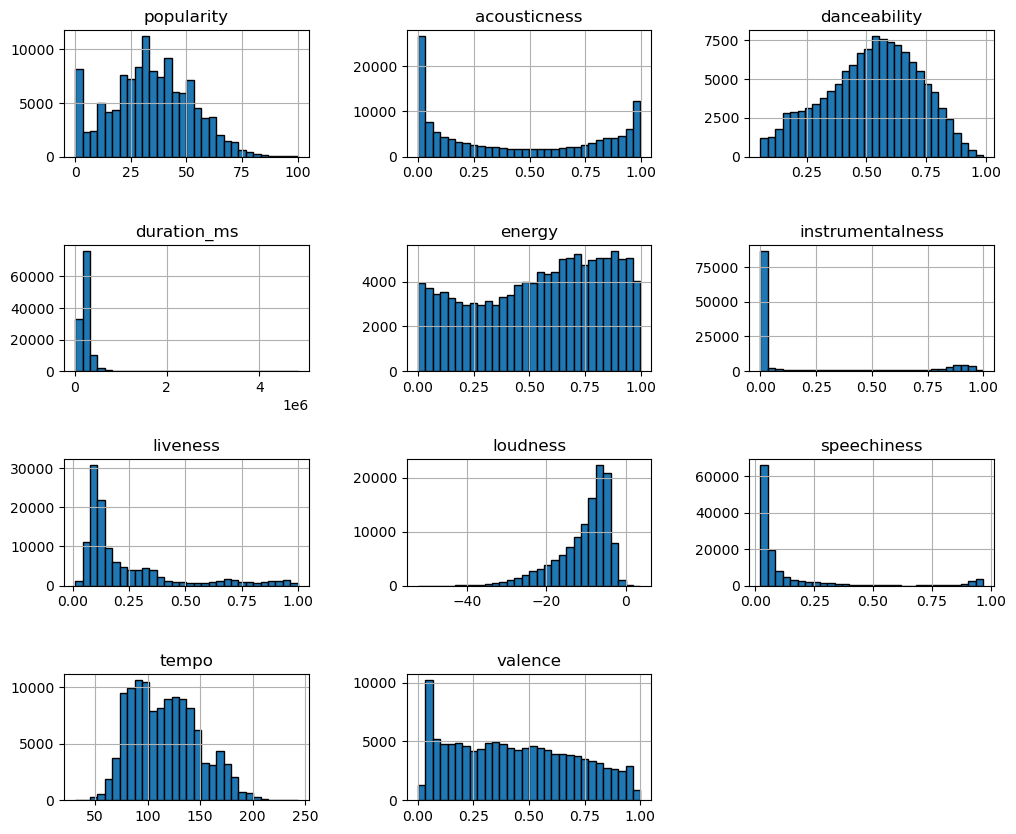

In [48]:
df.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
df.describe()
# all the songs

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,70.320988,0.187546,0.639481,206759.160494,0.611951,0.000731,0.179156,-6.086432,0.101717,113.998667,0.443383
std,13.475744,0.195579,0.110530,42480.990141,0.162939,0.006059,0.123233,1.779724,0.100597,25.811946,0.200045
min,46.000000,0.000462,0.381000,65693.000000,0.281000,0.000000,0.028000,-11.774000,0.027000,62.520000,0.054900
25%,62.000000,0.040000,0.590000,190440.000000,0.475000,0.000000,0.099000,-6.897000,0.037700,99.034000,0.300000
50%,70.000000,0.100000,0.652000,207333.000000,0.628000,0.000000,0.129000,-5.772000,0.055300,108.801000,0.398000
75%,78.000000,0.280000,0.710000,227027.000000,0.734000,0.000007,0.235000,-5.290000,0.129000,129.956000,0.587000
max,100.000000,0.780000,0.877000,339733.000000,0.879000,0.054500,0.751000,-2.775000,0.465000,191.708000,0.855000


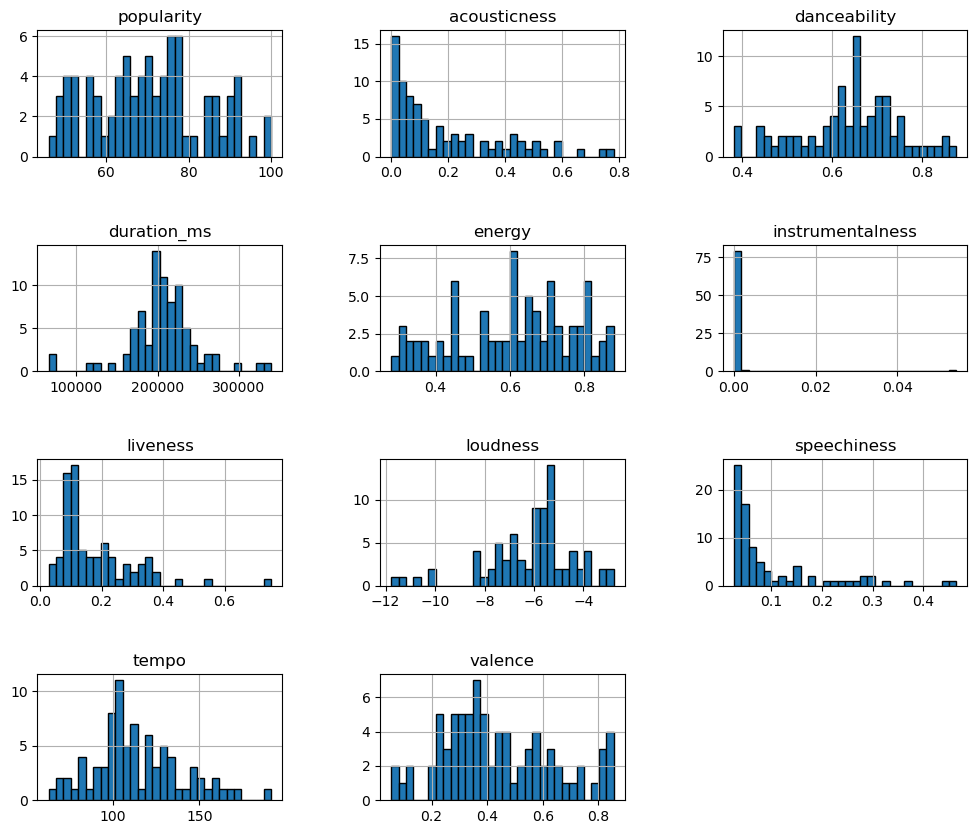

In [49]:
# charts for ariana
import matplotlib.pyplot as plt
ari = df[df['artist_name']== 'Ariana Grande']
ari.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
ari.describe()


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,58.567568,0.097741,0.660946,203220.648649,0.754000,0.003724,0.190865,-5.074378,0.072235,112.394081,0.529214
std,11.553115,0.122734,0.103073,33683.963861,0.152073,0.021851,0.145014,1.617581,0.038545,17.282518,0.217382
min,42.000000,0.000718,0.392000,50613.000000,0.414000,0.000000,0.059500,-9.985000,0.025900,79.979000,0.067900
25%,51.000000,0.014800,0.607000,189333.000000,0.673000,0.000000,0.097300,-6.271000,0.041300,102.028000,0.362000
50%,54.000000,0.053000,0.684000,208048.000000,0.781000,0.000000,0.127000,-4.874000,0.061100,109.979000,0.526000
75%,67.000000,0.142000,0.717000,221280.000000,0.882000,0.000003,0.214000,-3.982000,0.098300,124.911000,0.717000
max,86.000000,0.603000,0.965000,254852.000000,0.974000,0.133000,0.631000,-2.620000,0.165000,157.988000,0.935000


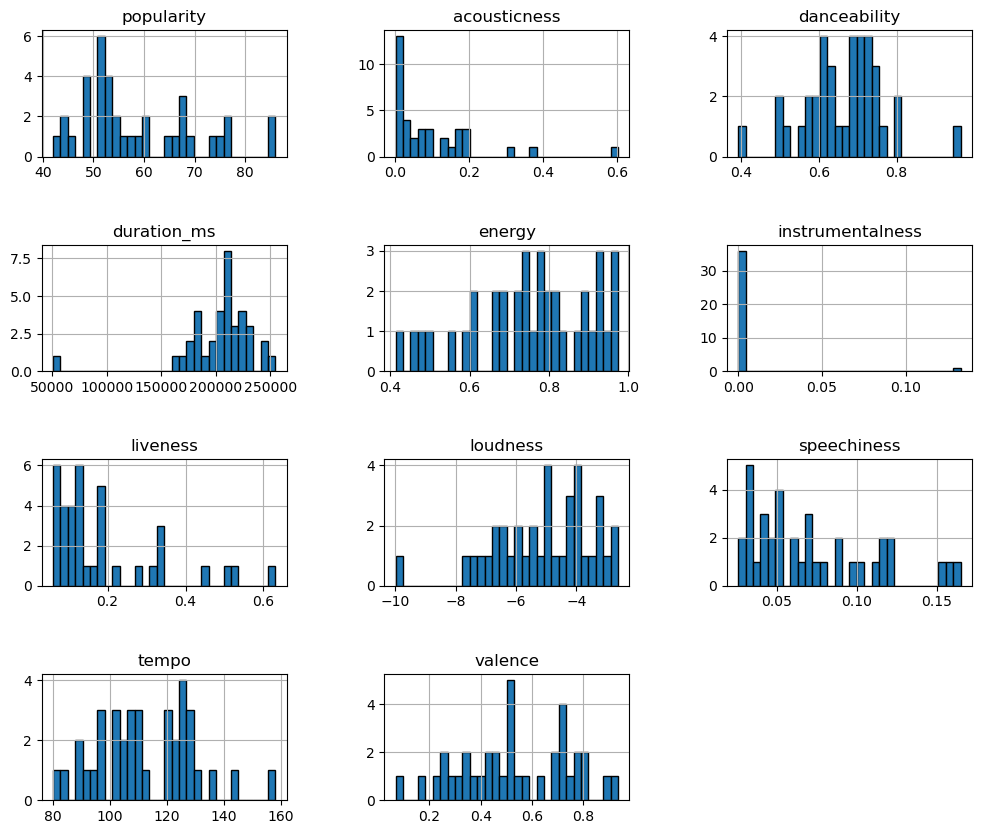

In [ ]:
import matplotlib.pyplot as plt
selena = df[df['artist_name']== 'Selena Gomez']
selena.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
selena.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,58.114943,0.063102,0.548448,222791.367816,0.841529,0.044554,0.267861,-5.225977,0.077814,122.306172,0.455154
std,10.575779,0.100018,0.083306,56799.111789,0.158297,0.164527,0.226348,2.001518,0.061110,27.449547,0.195329
min,38.000000,0.000220,0.291000,71893.000000,0.175000,0.000000,0.044400,-15.587000,0.023800,80.012000,0.040400
25%,52.000000,0.007755,0.492500,189546.500000,0.753000,0.000000,0.104500,-6.095500,0.036200,100.016500,0.310500
50%,57.000000,0.028700,0.546000,212293.000000,0.908000,0.000002,0.178000,-4.580000,0.050800,115.000000,0.451000
75%,66.000000,0.063550,0.597000,250587.000000,0.960000,0.003700,0.326000,-3.993000,0.099200,139.982000,0.591000
max,84.000000,0.617000,0.750000,395067.000000,0.995000,0.929000,0.968000,-2.597000,0.302000,199.972000,0.938000


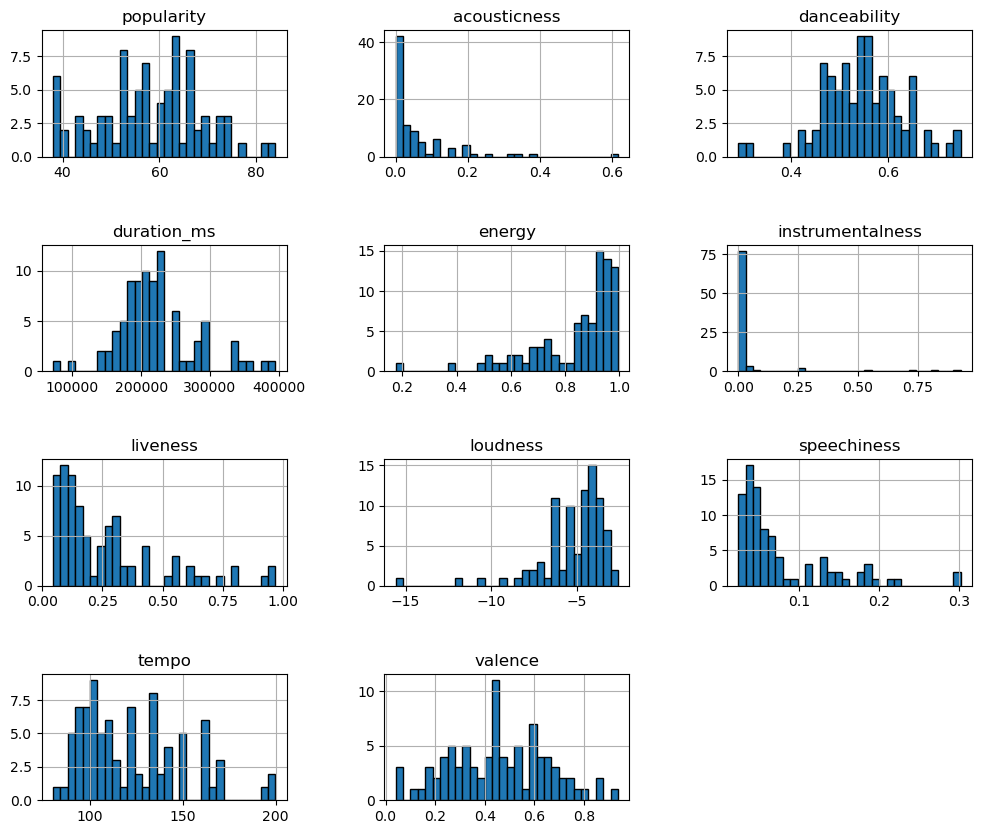

In [ ]:
import matplotlib.pyplot as plt
park = df[df['artist_name']== 'Linkin Park']
park.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
park.describe()